# Notebook 4 — Limpieza y Transformación de los Datos
## Fuente: NIST Atomic Spectra Database (ASD)
## Proyecto: Óptica y Fotónica — Primer Parcial

**Estudiante:** Perez Criollo Andres David
**Entrada:** `datos_originales/` (archivos crudos, **nunca se modifican**)
**Salida:** `datos_procesados/`
**Plan que se ejecuta:** `docs/PLAN_limpieza_datos.md` (decisiones L1 … L14)
**Diagnóstico de partida:** `notebooks/03_exploracion_caracterizacion_datos.ipynb`

---

### Pregunta científica que orienta cada decisión

> **¿Cómo se distribuyen las líneas espectrales de los primeros diez elementos de la tabla
> periódica (H a Ne) a lo largo del espectro electromagnético, y qué relación existe entre
> la probabilidad de transición espontánea (coeficiente de Einstein Aki) y la longitud de
> onda de emisión en cada elemento?**

---

### El principio que gobierna toda esta limpieza

> **En un dataset científico, un valor ausente es información.**

Que el NIST no haya medido el `Aki` de una línea no es un hueco que haya que tapar: es un
hecho sobre el estado del conocimiento experimental. Por eso esta limpieza es
**deliberadamente conservadora**:

- **No se imputa ni un solo valor** en las variables críticas (longitud de onda, `Aki`,
  energías, elemento).
- **No se elimina ningún valor atípico**: en física atómica un atípico estadístico suele ser
  una transición real pero poco común.
- Solo se eliminan **2 filas** en todo el proceso, y no son observaciones sino cabeceras
  incrustadas.
- Solo se descartan **4 columnas**, todas secundarias y con más del 69 % de ausencias.

La ganancia no viene de rellenar huecos, sino de **decodificar correctamente** el formato e
**interpretar la notación** propia del NIST.

---

### Qué se encontró en la exploración (resumen de entrada)

| Hallazgo | Cifra |
|---|---|
| Valores ausentes escondidos tras el envoltorio `="..."` | **80 697** (66 509 en líneas + 14 188 en niveles) |
| Filas con longitud de onda medida en **aire** mezcladas con las de vacío | **10 428** de 18 288 |
| Valores no convertibles por la notación propia del NIST | 28 020 en líneas |
| Valores **físicamente imposibles** | **0** |
| Filas exactamente duplicadas | **0** |
| Cumplimiento de `g = 2J + 1` | **100 %** |

**El dataset no está sucio: está codificado.**

---
# Sección 1 — Carga de los datos originales

Los archivos de `datos_originales/` se abren **en modo lectura** y no se modifican en ningún
momento. Son la evidencia de la fuente oficial que exige la rúbrica, y todo el proceso debe
poder reconstruirse a partir de ellos.

No hay peticiones de red en este notebook: la descarga ya ocurrió y quedó documentada en el
notebook 03.

In [1]:
import os
import re
import hashlib
from datetime import datetime
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 4.5)

DIR_ORIGINALES = "datos_originales"
DIR_PROCESADOS = "datos_procesados"
os.makedirs(DIR_PROCESADOS, exist_ok=True)

RUTA_LINES = os.path.join(DIR_ORIGINALES, "nist_lines_H_Ne_original.csv")
RUTA_LEVELS = os.path.join(DIR_ORIGINALES, "nist_levels_todos_original.csv")

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"Ejecutado el {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()
print("Archivos de entrada (solo lectura):")
for ruta in (RUTA_LINES, RUTA_LEVELS):
    with open(ruta, "rb") as f:
        huella = hashlib.md5(f.read()).hexdigest()
    print(f"  {ruta}")
    print(f"     {os.path.getsize(ruta):>12,} bytes   md5={huella}")

pandas 3.0.5 | numpy 2.5.2
Ejecutado el 2026-09-19 23:13:49

Archivos de entrada (solo lectura):
  datos_originales/nist_lines_H_Ne_original.csv
        5,418,514 bytes   md5=d193a8f9d29ddf87b8612b734a33385d
  datos_originales/nist_levels_todos_original.csv
          888,532 bytes   md5=85a2ee1ce39d419b62a585b53a326727


### Ayudantes reutilizados del notebook 03

Son las mismas funciones que se validaron durante la exploración. Se repiten aquí para que
este notebook sea autocontenido y pueda ejecutarse sin depender del anterior.

**Atención a un detalle de `pandas` 3:** la guarda para saltar columnas numéricas debe ser
`pd.api.types.is_numeric_dtype(...)` y **no** `col.dtype != object`. En pandas 3 las columnas
de texto tienen un dtype `str` propio, así que la comparación contra `object` las excluiría
por error y dejaría el envoltorio intacto — que fue exactamente el error que se detectó y
corrigió durante la exploración.

In [2]:
def parsear_csv_nist(texto, nombre_espectro=None):
    # El NIST intercala lineas vacias y separadores de guiones que hay que descartar
    # ANTES de pasarle el texto a pandas.
    lineas = [ln for ln in texto.split("\n") if ln.strip() and not ln.startswith("---")]
    df = pd.read_csv(StringIO("\n".join(lineas)), sep=",", low_memory=False, on_bad_lines="warn")
    # La cabecera del NIST termina en coma: pandas inventa una columna 'Unnamed: N' vacia.
    fantasmas = [c for c in df.columns if str(c).startswith("Unnamed:") and df[c].isna().all()]
    if fantasmas:
        df = df.drop(columns=fantasmas)
    if nombre_espectro is not None:
        df.insert(0, "espectro", nombre_espectro)
    return df


def decodificar_exportacion(df):
    # Deshace el envoltorio ="valor" del CSV del NIST y convierte en NaN las cadenas vacias
    # resultantes, que es lo que realmente significan.
    # NO altera el contenido: ="91.23" y 91.23 son exactamente el mismo dato.
    salida = df.copy()
    for col in salida.columns:
        if pd.api.types.is_numeric_dtype(salida[col]):
            continue
        s = salida[col].astype(str).str.strip()
        s = s.str.replace(r'^="', "", regex=True).str.replace(r'"$', "", regex=True).str.strip()
        salida[col] = s.replace({"": np.nan, "nan": np.nan, "None": np.nan}).mask(salida[col].isna())
    return salida


def resumen(df, etiqueta):
    print(f"{etiqueta:<42} {df.shape[0]:>7,} filas x {df.shape[1]:>3} columnas   "
          f"nulos={int(df.isna().sum().sum()):>8,}")


# Bitacora de la limpieza: cada paso deja registro de su efecto.
BITACORA = []


def registrar(paso, descripcion, filas, columnas, detalle=""):
    BITACORA.append({
        "paso": paso, "descripcion": descripcion,
        "filas": filas, "columnas": columnas, "detalle": detalle,
    })
    print(f"[{paso}] {descripcion}")
    print(f"      -> {filas:,} filas x {columnas} columnas   {detalle}")


print("Ayudantes definidos.")

Ayudantes definidos.


## 1.1 — Reconstrucción del medio (aire / vacío) desde el archivo crudo

**Este paso tiene que ocurrir durante la carga, antes de filtrar o reordenar nada**, porque
la única forma de saber en qué medio se midió cada línea es **la posición que ocupa en el
archivo original**.

La exploración reveló que la respuesta del NIST no es un único bloque, sino **tres**, cada
uno con su propia cabecera:

| Bloque | Filas | Cabecera | Medio |
|---|---|---|---|
| 1 | 3 689 | `obs_wl_vac(nm)` | vacío |
| 2 | **10 428** | `obs_wl_air(nm)` | **aire** |
| 3 | 4 171 | `obs_wl_vac(nm)` | vacío |

Como `pandas` solo interpreta la primera cabecera, las otras dos quedaron **incrustadas como
filas de datos** y las 10 428 mediciones en aire terminaron bajo una columna llamada
`obs_wl_vac(nm)`. Es el defecto más silencioso del dataset: no produce ningún error, produce
una columna que *parece* homogénea y no lo es.

In [3]:
with open(RUTA_LINES, "r", encoding="utf-8") as f:
    texto_lines = f.read()

# Misma lista de lineas utiles que usa parsear_csv_nist, para que los indices cuadren.
utiles = [ln for ln in texto_lines.split("\n") if ln.strip() and not ln.startswith("---")]
cortes = [i for i, ln in enumerate(utiles) if ln.startswith("element,sp_num")]

print(f"Lineas utiles en el archivo : {len(utiles):,}")
print(f"Cabeceras encontradas en    : {cortes}")
print()

medio_por_bloque = {}
for j, ini in enumerate(cortes):
    fin = cortes[j + 1] if j + 1 < len(cortes) else len(utiles)
    etiqueta = "aire" if "obs_wl_air" in utiles[ini] else "vacio"
    medio_por_bloque[ini] = etiqueta
    print(f"  Bloque {j + 1}: filas {ini + 1}..{fin - 1}  ->  {fin - 1 - ini:>6,} filas   medio={etiqueta}")

# A cada fila de datos (utiles[1:]) le corresponde el medio del bloque que la contiene.
medio_filas = []
for idx in range(1, len(utiles)):
    bloque = max(c for c in cortes if c <= idx)
    medio_filas.append(medio_por_bloque[bloque])

print()
print(f"Etiquetas de medio generadas: {len(medio_filas):,}")
print(pd.Series(medio_filas).value_counts().to_string())

Lineas utiles en el archivo : 18,291
Cabeceras encontradas en    : [0, 3690, 14119]

  Bloque 1: filas 1..3689  ->   3,689 filas   medio=vacio
  Bloque 2: filas 3691..14118  ->  10,428 filas   medio=aire
  Bloque 3: filas 14120..18290  ->   4,171 filas   medio=vacio

Etiquetas de medio generadas: 18,290
aire     10429
vacio     7861


In [4]:
df_lines_raw = parsear_csv_nist(texto_lines)
df_levels_raw = pd.read_csv(RUTA_LEVELS, low_memory=False)

assert len(df_lines_raw) == len(medio_filas), "Desalineacion entre el texto crudo y el parseo"
df_lines_raw["medio"] = medio_filas

resumen(df_lines_raw, "LINEAS (crudo, con artefacto)")
resumen(df_levels_raw, "NIVELES (crudo, con artefacto)")
print()
print("Columnas de LINEAS :", list(df_lines_raw.columns))
print()
print("Columnas de NIVELES:", list(df_levels_raw.columns))

LINEAS (crudo, con artefacto)               18,290 filas x  27 columnas   nulos=  23,640
NIVELES (crudo, con artefacto)               5,752 filas x  13 columnas   nulos=   8,825

Columnas de LINEAS : ['element', 'sp_num', 'obs_wl_vac(nm)', 'unc_obs_wl', 'ritz_wl_vac(nm)', 'unc_ritz_wl', 'intens', 'Aki(s^-1)', 'fik', 'log_gf', 'Acc', 'Ei(cm-1)', 'Ek(cm-1)', 'conf_i', 'term_i', 'J_i', 'conf_k', 'term_k', 'J_k', 'g_i', 'g_k', 'Type', 'tp_ref', 'line_ref', 'ID_i', 'ID_k', 'medio']

Columnas de NIVELES: ['espectro', 'Configuration', 'Term', 'J', 'g', 'Prefix', 'Level (eV)', 'Suffix', 'Uncertainty (eV)', 'Leading percentages', 'Level ID', 'Reference', 'Lande']


---
# Sección 2 — L3: decodificar el envoltorio de exportación

Se adelanta este paso porque **hasta que no se haga, los valores ausentes son invisibles** y
ninguna otra decisión es evaluable.

El NIST exporta cada valor envuelto como `="valor"` para que Excel no lo reinterprete. Tras
el parseo eso deja dos problemas:

1. Todas las columnas quedan como texto, incluidas longitud de onda y `Aki`.
2. **Un dato ausente llega como la cadena `=""`, no como `NaN`** — así que `isnull()`
   informaría cero nulos en todo el dataset.

Decodificar **no es limpiar**: es deshacer el envoltorio para recuperar el valor que el NIST
quiso transmitir. `="91.23"` y `91.23` son el mismo dato.

In [5]:
df_lines = decodificar_exportacion(df_lines_raw)
df_levels = decodificar_exportacion(df_levels_raw)

comparativa = pd.DataFrame([
    {"fuente": "LINEAS",
     "nulos_antes_de_decodificar": int(df_lines_raw.isna().sum().sum()),
     "nulos_reales": int(df_lines.isna().sum().sum())},
    {"fuente": "NIVELES",
     "nulos_antes_de_decodificar": int(df_levels_raw.isna().sum().sum()),
     "nulos_reales": int(df_levels.isna().sum().sum())},
])
comparativa["ausencias_que_estaban_ocultas"] = (
    comparativa["nulos_reales"] - comparativa["nulos_antes_de_decodificar"]
)
display(comparativa)

print(f"Total de ausencias que el envoltorio escondia: "
      f"{int(comparativa['ausencias_que_estaban_ocultas'].sum()):,}")

registrar("L3", "Decodificado el envoltorio de exportacion",
          len(df_lines), df_lines.shape[1],
          f"{int(comparativa['ausencias_que_estaban_ocultas'].sum()):,} ausencias reveladas")

,fuente,nulos_antes_de_decodificar,nulos_reales,ausencias_que_estaban_ocultas
0,LINEAS,23640,90149,66509
1,NIVELES,8825,23013,14188


Total de ausencias que el envoltorio escondia: 80,697
[L3] Decodificado el envoltorio de exportacion
      -> 18,290 filas x 27 columnas   80,697 ausencias reveladas


---
# Sección 3 — L1: eliminar las filas de cabecera incrustadas

**Único paso de todo el proceso que elimina filas.** Se eliminan porque **no son
observaciones**: son metadatos del formato que quedaron mezclados con los datos. No
representan ninguna transición física.

Se ejecuta después de asignar el medio (Sección 1.1) porque esa asignación dependía de la
posición original de cada fila.

In [6]:
antes = len(df_lines)
mascara_cabecera = df_lines["element"] == "element"

print(f"Filas de cabecera detectadas: {int(mascara_cabecera.sum())}")
display(df_lines[mascara_cabecera].iloc[:, :8])

df_toclean = df_lines[~mascara_cabecera].reset_index(drop=True).copy()

print(f"\nFilas antes : {antes:,}")
print(f"Filas ahora : {len(df_toclean):,}")
print(f"Eliminadas  : {antes - len(df_toclean)}")
print()
print("Verificacion: la columna 'element' ya solo contiene simbolos quimicos reales")
print(sorted(df_toclean["element"].dropna().unique()))

registrar("L1", "Eliminadas las cabeceras incrustadas",
          len(df_toclean), df_toclean.shape[1], f"-{antes - len(df_toclean)} filas")

Filas de cabecera detectadas: 2


,element,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1)
3689,element,sp_num,obs_wl_air(nm),unc_obs_wl,ritz_wl_air(nm),unc_ritz_wl,intens,Aki(s^-1)
14118,element,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1)



Filas antes : 18,290
Filas ahora : 18,288
Eliminadas  : 2

Verificacion: la columna 'element' ya solo contiene simbolos quimicos reales
['B', 'Be', 'C', 'F', 'H', 'He', 'Li', 'N', 'Ne', 'O']
[L1] Eliminadas las cabeceras incrustadas
      -> 18,288 filas x 27 columnas   -2 filas


---
# Sección 4 — L2: unificar la longitud de onda a una sola convención

La longitud de onda de una línea se puede expresar **medida en el vacío** o **medida en el
aire**, y los dos valores difieren porque el aire desvía ligeramente la luz. El NIST alterna
entre ambas según el rango, y la mezcla quedó sin marcar.

**Justificación física:** la diferencia es de ~0,03 %, pequeña pero **sistemática**. Como la
longitud de onda es la variable central de la pregunta científica y se usa para comparar
elementos entre sí, una columna que mezcla dos definiciones distintas **no es una variable**.

**Justificación computacional:** se conserva la columna original y se **añade** una columna
homogénea, sin destruir nada. El índice de refracción del aire en condiciones estándar es
n = 1,00028, y la conversión es λ_vacío = λ_aire × n.

In [7]:
N_AIRE = 1.00028   # indice de refraccion del aire en condiciones estandar

col_obs = "obs_wl_vac(nm)"
col_ritz = "ritz_wl_vac(nm)"

print("Distribucion del medio de medicion:")
display(df_toclean["medio"].value_counts().to_frame("lineas"))

obs_num = pd.to_numeric(df_toclean[col_obs], errors="coerce")
es_aire = df_toclean["medio"] == "aire"

print(f"Lineas medidas en AIRE con longitud de onda observada : {int((es_aire & obs_num.notna()).sum()):,}")
print(f"Lineas medidas en VACIO con longitud de onda observada: {int((~es_aire & obs_num.notna()).sum()):,}")
print()
print("Efecto de la conversion sobre un ejemplo en aire:")
ejemplo = df_toclean.loc[es_aire & obs_num.notna()].head(3).index
display(pd.DataFrame({
    "medio": df_toclean.loc[ejemplo, "medio"],
    "lambda_original_nm": obs_num[ejemplo],
    "lambda_en_vacio_nm": (obs_num[ejemplo] * N_AIRE).round(6),
    "diferencia_nm": (obs_num[ejemplo] * N_AIRE - obs_num[ejemplo]).round(6),
}))

registrar("L2", "Reconstruido el medio de medicion (aire/vacio)",
          len(df_toclean), df_toclean.shape[1],
          f"{int(es_aire.sum()):,} filas en aire identificadas")

Distribucion del medio de medicion:


,lineas
medio,
aire,10428
vacio,7860


Lineas medidas en AIRE con longitud de onda observada : 6,462
Lineas medidas en VACIO con longitud de onda observada: 3,402

Efecto de la conversion sobre un ejemplo en aire:


,medio,lambda_original_nm,lambda_en_vacio_nm,diferencia_nm
3690,aire,200.18752,200.243573,0.056053
3691,aire,200.39300,200.449110,0.056110
3692,aire,200.48270,200.538835,0.056135


[L2] Reconstruido el medio de medicion (aire/vacio)
      -> 18,288 filas x 27 columnas   10,428 filas en aire identificadas


---
# Sección 5 — L4: interpretar la notación del NIST en vez de descartarla

**Esta es la decisión que más datos salva.**

La exploración encontró 28 020 valores que `pd.to_numeric(errors='coerce')` convertiría en
`NaN`. Pero no son basura: son **notación científica con significado**:

| Símbolo | Significado | Dónde |
|---|---|---|
| `[186101.55]` | Energía **interpolada o teórica**, no medida experimentalmente | `Ei`, `Ek` |
| `934593.0+x` | Energía referida a un **origen desconocido** | `Ei`, `Ek` |
| `74.4794+` | Longitud de onda Ritz que es un **límite**, no un valor exacto | `ritz_wl` |
| `500*`, `a*`, `a` | Banderas de intensidad (línea difusa, mezclada, autoabsorbida…) | `intens` |

**Diferencia clave con el ejemplo de clase:** allí, el texto `tbd` en `User_Score` era ruido
sin contenido y convertirlo en `NaN` era correcto. Aquí, `[186101.55]` **sí contiene la
energía**: los corchetes informan *cómo se obtuvo*, no la anulan.

Por eso, para cada símbolo se extrae **el valor numérico** y se conserva **su significado**
en una columna aparte. Así nada se pierde y después se puede filtrar por calidad si se quiere.

In [8]:
def extraer_energia(serie):
    # Separa el numero de las marcas del NIST:
    #   [valor] -> energia interpolada o teorica
    #   valor+x -> energia relativa a un origen desconocido
    s = serie.astype(str)
    interpolada = s.str.contains(r"\[", na=False)
    origen_desconocido = s.str.contains(r"\+[xy]", na=False)
    limpio = (
        s.str.replace(r"[\[\]]", "", regex=True)
        .str.replace(r"\+[xyzXYZ]", "", regex=True)
        .str.strip()
    )
    valor = pd.to_numeric(limpio, errors="coerce")
    return valor, interpolada.where(serie.notna()), origen_desconocido.where(serie.notna())


for origen, destino in [("Ei(cm-1)", "energia_inferior_cm1"), ("Ek(cm-1)", "energia_superior_cm1")]:
    antes_validos = int(pd.to_numeric(df_toclean[origen], errors="coerce").notna().sum())
    valor, interp, desc = extraer_energia(df_toclean[origen])
    df_toclean[destino] = valor
    df_toclean[destino + "_interpolada"] = interp
    df_toclean[destino + "_origen_desconocido"] = desc
    print(f"{origen:<12} valores numericos con coerce ingenuo: {antes_validos:>7,}")
    print(f"{'':<12} valores recuperados interpretando marcas: {int(valor.notna().sum()):>7,}   "
          f"(+{int(valor.notna().sum()) - antes_validos:,})")
    print(f"{'':<12} marcadas como interpoladas: {int(interp.sum()):>6,} | "
          f"origen desconocido: {int(desc.sum()):,}")
    print()

Ei(cm-1)     valores numericos con coerce ingenuo:  14,634
             valores recuperados interpretando marcas:  18,044   (+3,410)
             marcadas como interpoladas:  2,999 | origen desconocido: 408

Ek(cm-1)     valores numericos con coerce ingenuo:  14,117
             valores recuperados interpretando marcas:  17,807   (+3,690)
             marcadas como interpoladas:  3,376 | origen desconocido: 413



In [9]:
# Longitud de onda Ritz: el sufijo '+' indica que el valor es un limite, no una medida exacta.
s_ritz = df_toclean[col_ritz].astype(str)
df_toclean["longitud_onda_ritz_nm"] = pd.to_numeric(
    s_ritz.str.replace(r"\+$", "", regex=True).str.strip(), errors="coerce"
)
df_toclean["ritz_es_limite"] = s_ritz.str.endswith("+", na=False).where(df_toclean[col_ritz].notna())

antes_ritz = int(pd.to_numeric(df_toclean[col_ritz], errors="coerce").notna().sum())
print(f"Ritz con coerce ingenuo      : {antes_ritz:,}")
print(f"Ritz interpretando el sufijo : {int(df_toclean['longitud_onda_ritz_nm'].notna().sum()):,} "
      f"(+{int(df_toclean['longitud_onda_ritz_nm'].notna().sum()) - antes_ritz:,})")
print(f"Marcadas como limite         : {int(df_toclean['ritz_es_limite'].sum()):,}")

# La longitud de onda observada no trae marcas, pero se convierte con el mismo criterio.
df_toclean["longitud_onda_obs_nm"] = pd.to_numeric(df_toclean[col_obs], errors="coerce")

Ritz con coerce ingenuo      : 17,892
Ritz interpretando el sufijo : 18,106 (+214)
Marcadas como limite         : 214


In [10]:
# Intensidad: el NIST mezcla el numero con banderas de calidad de la linea.
s_int = df_toclean["intens"].astype(str)
df_toclean["intensidad_valor"] = pd.to_numeric(
    s_int.str.extract(r"([0-9]*\.?[0-9]+(?:[eE][+-]?[0-9]+)?)")[0], errors="coerce"
)
banderas = s_int.str.replace(r"[0-9.]", "", regex=True).str.strip()
df_toclean["intensidad_bandera"] = banderas.replace("", np.nan).where(df_toclean["intens"].notna())

antes_int = int(pd.to_numeric(df_toclean["intens"], errors="coerce").notna().sum())
print(f"Intensidad con coerce ingenuo    : {antes_int:,}")
print(f"Intensidad separando la bandera  : {int(df_toclean['intensidad_valor'].notna().sum()):,} "
      f"(+{int(df_toclean['intensidad_valor'].notna().sum()) - antes_int:,})")
print()
print("Banderas de intensidad encontradas:")
display(df_toclean["intensidad_bandera"].value_counts().head(10).to_frame("frecuencia"))

registrar("L4", "Interpretada la notacion cientifica del NIST",
          len(df_toclean), df_toclean.shape[1],
          "energias, Ritz e intensidad con valor + bandera separados")

Intensidad con coerce ingenuo    : 6,112
Intensidad separando la bandera  : 8,986 (+2,874)

Banderas de intensidad encontradas:


,frecuencia
intensidad_bandera,
*,1909
a*,381
bl*,209
a,191
bl,159
w*,94
h*,75
w,72
(),71


[L4] Interpretada la notacion cientifica del NIST
      -> 18,288 filas x 38 columnas   energias, Ritz e intensidad con valor + bandera separados


---
# Sección 6 — L5: convertir J de fracción a número

El número cuántico **J** viene escrito como fracción (`3/2`) en cerca del 46 % de los casos.
`pd.to_numeric` los convertiría todos en `NaN`, cuando `3/2` es simplemente 1,5.

Pero hay que ser cuidadoso: la exploración de esta fase reveló que los valores **no
resueltos** son más variados de lo esperado — además de `---` aparecen `0,1,2`, `1,2,3`,
`2,3,4`, `1/2,3/2`, `3/2,5/2` e incluso `1/2 or 3/2`. Son casos en que el NIST **no ha
determinado** un único valor de J.

Por eso el parseo usa una **expresión regular estricta** en lugar de partir por `/`: solo
convierte lo que es inequívocamente una fracción o un entero, y todo lo demás queda como
no resuelto, conservando el texto original para no perder la información.

In [11]:
PATRON_J = re.compile(r"\d+(/\d+)?")


def parsear_J(v):
    # Solo convierte lo que es inequivocamente un entero o una fraccion simple.
    # '---', '0,1,2', '1/2 or 3/2' -> no resuelto (NaN)
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if not PATRON_J.fullmatch(s):
        return np.nan
    if "/" in s:
        a, b = s.split("/")
        return float(a) / float(b)
    return float(s)


for origen, destino in [("J_i", "j_inferior"), ("J_k", "j_superior")]:
    df_toclean[destino + "_texto"] = df_toclean[origen]
    df_toclean[destino] = df_toclean[origen].map(parsear_J)
    df_toclean[destino + "_resuelto"] = (
        df_toclean[destino].notna().where(df_toclean[origen].notna())
    )
    ingenuo = int(pd.to_numeric(df_toclean[origen], errors="coerce").notna().sum())
    print(f"{origen}: coerce ingenuo={ingenuo:>6,}  |  parseo de fracciones="
          f"{int(df_toclean[destino].notna().sum()):>6,}  "
          f"(+{int(df_toclean[destino].notna().sum()) - ingenuo:,})")

print()
no_resueltos = df_toclean.loc[
    df_toclean["J_i"].notna() & df_toclean["j_inferior"].isna(), "J_i"
]
print(f"Valores de J_i no resueltos: {len(no_resueltos):,}")
display(no_resueltos.value_counts().head(8).to_frame("frecuencia"))

J_i: coerce ingenuo= 9,558  |  parseo de fracciones=17,851  (+8,293)

J_k: coerce ingenuo= 9,470  |  parseo de fracciones=17,624  (+8,154)

Valores de J_i no resueltos: 4


,frecuencia
J_i,
"0,1,2",3
"1,2,3",1


In [12]:
# Mismo tratamiento en la tabla de niveles.
df_niv = df_levels.copy()
df_niv["j_texto"] = df_niv["J"]
df_niv["j_valor"] = df_niv["J"].map(parsear_J)
df_niv["j_resuelto"] = df_niv["j_valor"].notna().where(df_niv["J"].notna())
df_niv["g"] = pd.to_numeric(df_niv["g"], errors="coerce")

# VERIFICACION FISICA: por definicion la degeneracion es g = 2J + 1.
# Si el parseo de la fraccion fuese incorrecto, esta identidad fallaria.
ev = df_niv["j_valor"].notna() & df_niv["g"].notna()
cumple = (df_niv["g"] == 2 * df_niv["j_valor"] + 1) & ev

print(f"Niveles con J y g evaluables : {int(ev.sum()):,}")
print(f"Cumplen g = 2J + 1           : {int(cumple.sum()):,} ({cumple.sum() / ev.sum() * 100:.2f}%)")
print(f"Niveles con g pero SIN J     : {int((df_niv['g'].notna() & df_niv['j_valor'].isna()).sum()):,}")
print()
print("El 100% de cumplimiento confirma que la conversion de fracciones es correcta.")
print("Los niveles con g pero sin J son aquellos en que el NIST no resolvio J:")
print("su g si esta documentada, asi que NO se puede derivar g a partir de J.")
print("Esto tiene consecuencias directas sobre el diseno de la base de datos (3FN).")

assert cumple.sum() == ev.sum(), "Inconsistencia cuantica: el parseo de J es incorrecto"

registrar("L5", "Parseado J de fraccion a decimal",
          len(df_toclean), df_toclean.shape[1], "verificado con g = 2J+1 al 100%")

Niveles con J y g evaluables : 5,570
Cumplen g = 2J + 1           : 5,570 (100.00%)
Niveles con g pero SIN J     : 130

El 100% de cumplimiento confirma que la conversion de fracciones es correcta.
Los niveles con g pero sin J son aquellos en que el NIST no resolvio J:
su g si esta documentada, asi que NO se puede derivar g a partir de J.
Esto tiene consecuencias directas sobre el diseno de la base de datos (3FN).
[L5] Parseado J de fraccion a decimal
      -> 18,288 filas x 44 columnas   verificado con g = 2J+1 al 100%


---
# Sección 7 — L6: proteger los identificadores de nivel

`ID_i`, `ID_k` y `Level ID` **parecen** numéricos (`006002.000001`) pero son **códigos**.
Convertirlos a número los transforma en `6002.000001`, **destruyendo los ceros a la
izquierda** y rompiendo la unión entre las dos fuentes.

El criterio correcto no es si los valores *parsean* como número, sino si **son cantidades
sobre las que tiene sentido calcular**. Sobre un identificador no se puede promediar.

Durante la exploración este error llegó a degradar la unión; al protegerlos, la cobertura
subió al 98,81 %.

In [13]:
for col in ["ID_i", "ID_k"]:
    df_toclean[col] = df_toclean[col].astype("string")
df_niv["Level ID"] = df_niv["Level ID"].astype("string")

print("Verificacion: los identificadores conservan sus ceros a la izquierda")
for col, df in [("ID_i", df_toclean), ("ID_k", df_toclean), ("Level ID", df_niv)]:
    muestra = df[col].dropna().head(3).tolist()
    con_cero = df[col].dropna().astype(str).str.startswith("0").mean() * 100
    print(f"  {col:<10} ejemplos={muestra}   empiezan por cero: {con_cero:.1f}%")

print()
print("Contraejemplo de lo que pasaria si se convirtieran a numero:")
print(f"  '006002.000001'  ->  {float('006002.000001')}   (se pierden los ceros)")

registrar("L6", "Identificadores protegidos como texto",
          len(df_toclean), df_toclean.shape[1], "ID_i, ID_k, Level ID")

Verificacion: los identificadores conservan sus ceros a la izquierda
  ID_i       ejemplos=['006002.000001', '006002.000002', '006002.000004']   empiezan por cero: 100.0%
  ID_k       ejemplos=['006002.000359', '006002.000359', '006002.000367']   empiezan por cero: 100.0%
  Level ID   ejemplos=['001001.001.000001', '001001.001.000002', '001001.001.000004']   empiezan por cero: 100.0%

Contraejemplo de lo que pasaria si se convirtieran a numero:
  '006002.000001'  ->  6002.000001   (se pierden los ceros)
[L6] Identificadores protegidos como texto
      -> 18,288 filas x 44 columnas   ID_i, ID_k, Level ID


---
# Sección 8 — L7: normalizar las variables categóricas

**`Type`** está vacío en el 98,17 % de las filas, pero eso **no es un dato faltante**: por
convención del NIST, vacío significa **transición permitida (E1)**, el tipo más común. Se
rellena con la categoría explícita `E1` para que el significado quede documentado en el dato
en vez de escondido en una convención.

Es el caso análogo al `K-A` obsoleto del ejemplo de clase: una categoría que hay que
**entender** antes de tocarla.

**`Acc`** no es texto libre: es la **escala ordinal de exactitud** del NIST, de `AAA` (la
mejor) a `E` (la peor). Tratarla como categórica ordenada permite después filtrar por calidad
mínima del dato.

In [14]:
print("Valor de 'Type' antes de normalizar:")
display(df_toclean["Type"].value_counts(dropna=False).to_frame("frecuencia"))

# El valor '2P' aparece una sola vez y no es un tipo de transicion valido del NIST.
anomalos = df_toclean[df_toclean["Type"] == "2P"]
if len(anomalos):
    print(f"\nValor anomalo detectado: '2P' en {len(anomalos)} fila(s).")
    display(anomalos[["element", "sp_num", col_obs, "Aki(s^-1)", "Type", "term_k"]])
    print("No corresponde a ningun tipo de transicion del NIST (E1/E2/M1/M2/UT): parece un")
    print("termino espectroscopico desplazado de columna. Se marca como 'UT' (sin clasificar)")
    print("en vez de eliminarlo, porque el resto de la fila es valido.")
    df_toclean.loc[df_toclean["Type"] == "2P", "Type"] = "UT"

df_toclean["tipo_transicion"] = df_toclean["Type"].fillna("E1")

print()
print("Valor de 'tipo_transicion' despues de normalizar:")
display(df_toclean["tipo_transicion"].value_counts().to_frame("frecuencia"))

Valor de 'Type' antes de normalizar:


,frecuencia
Type,
NaN,17955
E2,167
M1,111
UT,37
M2,17
2P,1



Valor anomalo detectado: '2P' en 1 fila(s).


,element,sp_num,obs_wl_vac(nm),Aki(s^-1),Type,term_k
3098,Be,1,155.2110483,NaN,2P,1D


No corresponde a ningun tipo de transicion del NIST (E1/E2/M1/M2/UT): parece un
termino espectroscopico desplazado de columna. Se marca como 'UT' (sin clasificar)
en vez de eliminarlo, porque el resto de la fila es valido.

Valor de 'tipo_transicion' despues de normalizar:


,frecuencia
tipo_transicion,
E1,17955
E2,167
M1,111
UT,38
M2,17


In [15]:
ESCALA_ACC = ["AAA", "AA", "A+", "A", "B+", "B", "B'", "C+", "C", "C'", "D+", "D", "E"]

encontrados = set(df_toclean["Acc"].dropna().unique())
no_previstos = encontrados - set(ESCALA_ACC)
print(f"Codigos de exactitud encontrados : {len(encontrados)}")
print(f"Fuera de la escala documentada   : {no_previstos if no_previstos else 'ninguno'}")

df_toclean["exactitud"] = pd.Categorical(df_toclean["Acc"], categories=ESCALA_ACC, ordered=True)

print()
print("Distribucion de la exactitud (de mejor a peor):")
display(df_toclean["exactitud"].value_counts().reindex(ESCALA_ACC).to_frame("lineas"))

# Normalizacion de texto en las columnas categoricas restantes.
for col in ["element", "conf_i", "term_i", "conf_k", "term_k"]:
    df_toclean[col] = df_toclean[col].astype("string").str.strip()
for col in ["Configuration", "Term"]:
    df_niv[col] = df_niv[col].astype("string").str.strip()

registrar("L7", "Categoricas normalizadas",
          len(df_toclean), df_toclean.shape[1], "Type -> E1 explicito; Acc ordinal")

Codigos de exactitud encontrados : 13
Fuera de la escala documentada   : ninguno

Distribucion de la exactitud (de mejor a peor):


,lineas
exactitud,
AAA,2651
AA,743
A+,1
A,510
B+,500
B,1941
B',26
C+,1596
C,2047


[L7] Categoricas normalizadas
      -> 18,288 filas x 46 columnas   Type -> E1 explicito; Acc ordinal


---
# Sección 9 — L8: recuperar la longitud de onda con el respaldo Ritz

**La decisión de mayor impacto de toda la limpieza.**

La longitud de onda **observada** falta en el 46 % de las líneas. Pero el catálogo trae una
segunda columna, la **Ritz**, presente en el 97,8 %.

**Justificación física:** la longitud de onda Ritz **no es una estimación estadística**: es el
valor calculado a partir de la diferencia de energía entre los dos niveles del salto. Es
física exacta. Usarla como respaldo es científicamente legítimo; imputar con la mediana de la
columna produciría una línea espectral que no existe.

**Justificación computacional:** se conserva el origen de cada valor en
`longitud_onda_origen`, de modo que cualquier análisis posterior puede distinguir entre
medición y cálculo, o restringirse solo a las observadas.

In [16]:
df_toclean["longitud_onda_nm"] = df_toclean["longitud_onda_obs_nm"].fillna(
    df_toclean["longitud_onda_ritz_nm"]
)
df_toclean["longitud_onda_origen"] = np.where(
    df_toclean["longitud_onda_obs_nm"].notna(), "observada", "ritz"
)
df_toclean.loc[df_toclean["longitud_onda_nm"].isna(), "longitud_onda_origen"] = np.nan

# Columna homogenea en vacio (aplica la conversion L2 a la longitud de onda definitiva).
df_toclean["longitud_onda_vacio_nm"] = np.where(
    df_toclean["medio"] == "aire",
    df_toclean["longitud_onda_nm"] * N_AIRE,
    df_toclean["longitud_onda_nm"],
)

aki = pd.to_numeric(df_toclean["Aki(s^-1)"], errors="coerce")
n = len(df_toclean)
obs = df_toclean["longitud_onda_obs_nm"]
lam = df_toclean["longitud_onda_nm"]

tabla = pd.DataFrame([
    {"base de evidencia": "Solo con longitud de onda OBSERVADA y Aki",
     "lineas": int((obs.notna() & aki.notna()).sum())},
    {"base de evidencia": "Con longitud de onda OBSERVADA o RITZ y Aki",
     "lineas": int((lam.notna() & aki.notna()).sum())},
    {"base de evidencia": "Con alguna longitud de onda disponible",
     "lineas": int(lam.notna().sum())},
])
tabla["% del total"] = (tabla["lineas"] / n * 100).round(1)
display(tabla)

ganancia = int((lam.notna() & aki.notna()).sum()) - int((obs.notna() & aki.notna()).sum())
print(f"El respaldo Ritz aporta {ganancia:,} lineas adicionales SIN INVENTAR NINGUN DATO.")
print()
display(df_toclean["longitud_onda_origen"].value_counts(dropna=False).to_frame("lineas"))

registrar("L8", "Longitud de onda con respaldo Ritz",
          len(df_toclean), df_toclean.shape[1], f"+{ganancia:,} lineas utilizables")

,base de evidencia,lineas,% del total
0,Solo con longitud de onda OBSERVADA y Aki,4462,24.4
1,Con longitud de onda OBSERVADA o RITZ y Aki,12603,68.9
2,Con alguna longitud de onda disponible,18288,100.0


El respaldo Ritz aporta 8,141 lineas adicionales SIN INVENTAR NINGUN DATO.



,lineas
longitud_onda_origen,
observada,9864
ritz,8424


[L8] Longitud de onda con respaldo Ritz
      -> 18,288 filas x 49 columnas   +8,141 lineas utilizables


---
# Sección 10 — L9: `Aki` no se imputa

`Aki` falta en el 31 % de las líneas. **No se imputa.** Se conserva el `NaN` y se añade la
bandera `tiene_aki`.

**Aquí esta limpieza se aparta deliberadamente del ejemplo de clase.** Allí, imputar
`User_Count` con la mediana era razonable porque el objetivo era conservar filas para un
modelo. Aquí `Aki` **es la variable dependiente de la pregunta científica**: imputarla
equivale a inventar la respuesta.

Tres razones concretas:

1. **La distribución lo prohíbe:** `Aki` abarca 35 órdenes de magnitud con asimetría 40,16.
   Cualquier medida de centralidad es físicamente arbitraria sobre ese rango.
2. **El ejemplo de clase mostró el desenlace:** imputar con la mediana global colapsó los
   tres cuartiles al mismo valor y dejó la columna inservible.
3. **El faltante es informativo:** que Ne II tenga el 87,8 % de `Aki` ausente no es ruido,
   dice que ese ion está menos caracterizado experimentalmente. Imputarlo borraría un
   hallazgo del trabajo.

In [17]:
df_toclean["aki_s1"] = aki
df_toclean["tiene_aki"] = df_toclean["aki_s1"].notna()
df_toclean["fuerza_oscilador_fik"] = pd.to_numeric(df_toclean["fik"], errors="coerce")
df_toclean["log_gf"] = pd.to_numeric(df_toclean["log_gf"], errors="coerce")
df_toclean["incertidumbre_obs_nm"] = pd.to_numeric(df_toclean["unc_obs_wl"], errors="coerce")
df_toclean["incertidumbre_ritz_nm"] = pd.to_numeric(df_toclean["unc_ritz_wl"], errors="coerce")
df_toclean["g_inferior"] = pd.to_numeric(df_toclean["g_i"], errors="coerce")
df_toclean["g_superior"] = pd.to_numeric(df_toclean["g_k"], errors="coerce")

# Reconstruccion del espectro (elemento + estado de ionizacion en numeracion romana).
ROMANOS = {1: "I", 2: "II", 3: "III", 4: "IV", 5: "V"}
sp = pd.to_numeric(df_toclean["sp_num"], errors="coerce")
df_toclean["estado_ionizacion"] = sp.astype("Int8")
df_toclean["espectro"] = (
    df_toclean["element"].astype(str) + " " + sp.map(lambda v: ROMANOS.get(int(v)) if pd.notna(v) else None)
)

cobertura = df_toclean.groupby("espectro").agg(
    lineas=("aki_s1", "size"), con_aki=("aki_s1", "count")
)
cobertura["% con Aki"] = (cobertura["con_aki"] / cobertura["lineas"] * 100).round(1)
print("Cobertura de Aki por espectro (el sesgo que la imputacion habria borrado):")
display(cobertura.sort_values("% con Aki"))

registrar("L9", "Aki conservado sin imputar",
          len(df_toclean), df_toclean.shape[1],
          f"{int(df_toclean['tiene_aki'].sum()):,} con Aki, {int((~df_toclean['tiene_aki']).sum()):,} sin dato")

Cobertura de Aki por espectro (el sesgo que la imputacion habria borrado):


,lineas,con_aki,% con Aki
espectro,,,
Ne II,1914,233,12.2
Be II,681,149,21.9
Ne I,1597,533,33.4
F II,150,67,44.7
O II,1630,876,53.7
Be I,581,394,67.8
B I,371,269,72.5
B II,592,435,73.5
F I,162,120,74.1


[L9] Aki conservado sin imputar
      -> 18,288 filas x 58 columnas   12,603 con Aki, 5,685 sin dato


---
# Sección 11 — L10: variables derivadas para el análisis

Tres variables que no existen en el origen pero que la pregunta científica necesita:

- **`log10_aki`** — la correlación entre longitud de onda y `Aki` pasa de **−0,0023 en escala
  cruda a −0,6805 en log-log**. Sin la transformación logarítmica, la relación que se busca
  es literalmente invisible. No es un adorno: es la condición para poder responder.
- **`region_espectral`** — clasifica cada línea en ultravioleta, visible o infrarrojo, que es
  la primera mitad de la pregunta.
- **`energia_foton_ev`** — la energía del fotón emitido, derivada de la diferencia entre los
  dos niveles (1 eV = 8065,543937 cm⁻¹).

In [18]:
EV_A_CM1 = 8065.543937

df_toclean["log10_aki"] = np.log10(df_toclean["aki_s1"].where(df_toclean["aki_s1"] > 0))


def region_espectral(nm):
    if pd.isna(nm) or nm <= 0:
        return np.nan
    if nm < 10:
        return "Rayos X"
    if nm < 380:
        return "Ultravioleta"
    if nm <= 780:
        return "Visible"
    if nm <= 1e6:
        return "Infrarrojo"
    return "Microondas/Radio"


df_toclean["region_espectral"] = df_toclean["longitud_onda_vacio_nm"].map(region_espectral)
df_toclean["energia_foton_ev"] = (
    df_toclean["energia_superior_cm1"] - df_toclean["energia_inferior_cm1"]
) / EV_A_CM1

ORDEN_REG = ["Rayos X", "Ultravioleta", "Visible", "Infrarrojo", "Microondas/Radio"]
reg = df_toclean["region_espectral"].value_counts(dropna=False).reindex(ORDEN_REG + [np.nan]).dropna()
tabla_reg = reg.to_frame("lineas")
tabla_reg["%"] = (tabla_reg["lineas"] / len(df_toclean) * 100).round(2)
print("Distribucion por region del espectro electromagnetico:")
print("(antes de L8 el 46,07% quedaba 'sin dato'; el respaldo Ritz lo resuelve)")
display(tabla_reg)

print(f"Lineas sin region asignada: {int(df_toclean['region_espectral'].isna().sum()):,}")

registrar("L10", "Variables derivadas creadas",
          len(df_toclean), df_toclean.shape[1], "log10_aki, region_espectral, energia_foton_ev")

Distribucion por region del espectro electromagnetico:
(antes de L8 el 46,07% quedaba 'sin dato'; el respaldo Ritz lo resuelve)


,lineas,%
region_espectral,,
Rayos X,113.0,0.62
Ultravioleta,6347.0,34.71
Visible,3823.0,20.90
Infrarrojo,7926.0,43.34
Microondas/Radio,79.0,0.43


Lineas sin region asignada: 0
[L10] Variables derivadas creadas
      -> 18,288 filas x 61 columnas   log10_aki, region_espectral, energia_foton_ev


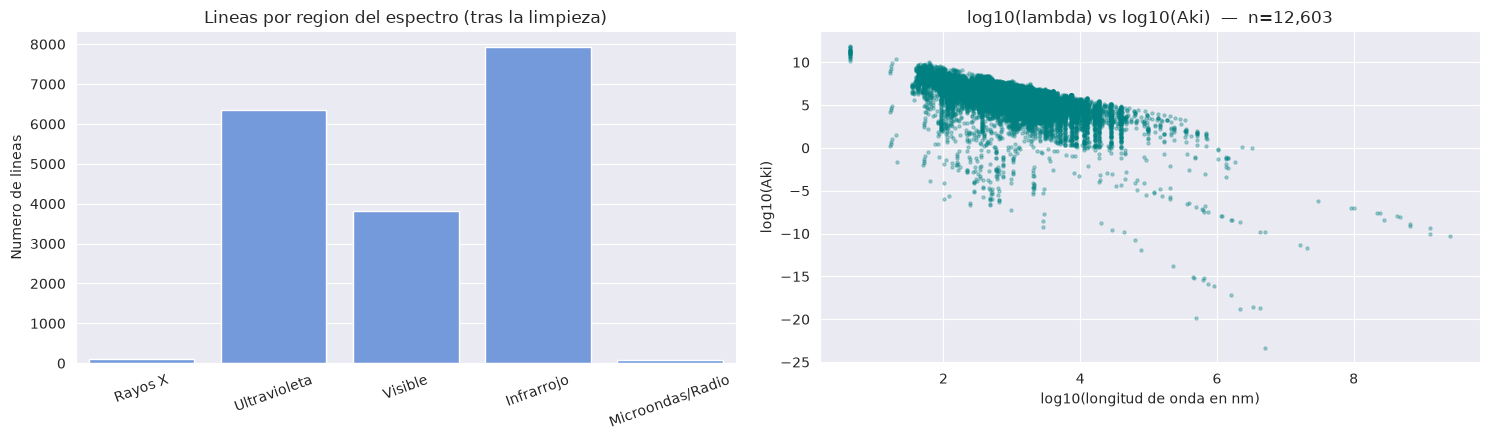

Correlacion de Pearson log-log: -0.6080


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(x=tabla_reg.index, y=tabla_reg["lineas"], ax=axes[0], color="cornflowerblue")
axes[0].set_title("Lineas por region del espectro (tras la limpieza)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Numero de lineas")
axes[0].tick_params(axis="x", rotation=20)

d = df_toclean[["longitud_onda_vacio_nm", "log10_aki", "element"]].dropna()
axes[1].scatter(np.log10(d["longitud_onda_vacio_nm"]), d["log10_aki"], s=5, alpha=0.3, color="teal")
axes[1].set_title(f"log10(lambda) vs log10(Aki)  —  n={len(d):,}")
axes[1].set_xlabel("log10(longitud de onda en nm)")
axes[1].set_ylabel("log10(Aki)")
plt.tight_layout()
plt.show()

r = np.log10(d["longitud_onda_vacio_nm"]).corr(d["log10_aki"])
print(f"Correlacion de Pearson log-log: {r:+.4f}")

---
# Sección 12 — L11: descartar las columnas sin valor informativo

El criterio no es solo el porcentaje de nulos, sino **el porcentaje de nulos combinado con la
irrelevancia para la pregunta científica**. `Ei` también tiene un 19 % de valores
problemáticos y **no se descarta**, porque es crítica.

| Columna | % nulos | Motivo |
|---|---|---|
| `Lande` | 99,50 % | Casi vacía, y los 29 valores presentes son estimaciones entre paréntesis |
| `Prefix` / `Suffix` | 78,79 % / 74,03 % | Solo marcan el corchete de energía interpolada: información ya capturada como bandera |
| `Leading percentages` | 69,38 % | Texto compuesto no estructurado, secundario para la pregunta |

**Se conservan** `unc_obs_wl` (57,94 % de nulos), `tp_ref` y `line_ref` pese a su alta
ausencia: documentan la calidad y la procedencia de cada medición, que la rúbrica exige poder
rastrear.

In [20]:
# Antes de descartar Prefix/Suffix hay que EXTRAER la informacion que contienen:
# Prefix == '[' marca que la energia del nivel es interpolada, no medida.
df_niv["energia_ev"] = pd.to_numeric(df_niv["Level (eV)"], errors="coerce")
df_niv["energia_interpolada"] = (df_niv["Prefix"].astype(str).str.strip() == "[")
df_niv["incertidumbre_ev"] = pd.to_numeric(df_niv["Uncertainty (eV)"], errors="coerce")

print("Informacion rescatada de Prefix antes de descartarlo:")
print(f"  Niveles con energia interpolada: {int(df_niv['energia_interpolada'].sum()):,} "
      f"({df_niv['energia_interpolada'].mean() * 100:.1f}%)")
print()

A_DESCARTAR = ["Lande", "Prefix", "Suffix", "Leading percentages"]
presentes = [c for c in A_DESCARTAR if c in df_niv.columns]

for c in presentes:
    print(f"  Descartada '{c}': {df_niv[c].isna().mean() * 100:.2f}% de nulos")

df_niv = df_niv.drop(columns=presentes)

registrar("L11", "Columnas sin valor informativo descartadas",
          len(df_niv), df_niv.shape[1], f"{len(presentes)} columnas: {presentes}")

Informacion rescatada de Prefix antes de descartarlo:
  Niveles con energia interpolada: 1,209 (21.0%)

  Descartada 'Lande': 99.50% de nulos
  Descartada 'Prefix': 78.79% de nulos
  Descartada 'Suffix': 74.03% de nulos
  Descartada 'Leading percentages': 69.38% de nulos
[L11] Columnas sin valor informativo descartadas
      -> 5,752 filas x 15 columnas   4 columnas: ['Lande', 'Prefix', 'Suffix', 'Leading percentages']


---
# Sección 13 — L12: duplicados — marcar, no eliminar

`drop_duplicates()` no encuentra **nada** que borrar: hay 0 filas exactamente duplicadas.

Pero sí hay 70 transiciones con la **misma identidad física** que aparecen más de una vez.
Esas filas difieren en la referencia bibliográfica: son **mediciones independientes de la
misma transición, publicadas por autores distintos**. Eso es información científica valiosa,
no basura.

**Decisión:** marcarlas con una bandera, no eliminarlas. Descartar una arbitrariamente
significaría tirar la medición de un laboratorio sin criterio. La decisión correcta se toma
en el modelo relacional, donde una transición podrá tener varias mediciones asociadas.

In [21]:
print(f"Filas exactamente duplicadas: {int(df_toclean.duplicated().sum())}")

clave_fisica = ["element", "sp_num", "longitud_onda_nm",
                "conf_i", "term_i", "J_i", "conf_k", "term_k", "J_k"]
df_toclean["medicion_repetida"] = df_toclean.duplicated(subset=clave_fisica, keep=False)

n_rep = int(df_toclean["medicion_repetida"].sum())
print(f"Filas que comparten identidad fisica con otra: {n_rep:,}")

if n_rep:
    ejemplo = df_toclean[df_toclean["medicion_repetida"]].sort_values(clave_fisica)
    print("\nEjemplo: misma transicion, distinta referencia bibliografica")
    display(ejemplo[["element", "sp_num", "longitud_onda_nm", "aki_s1",
                     "tp_ref", "line_ref"]].head(6))

registrar("L12", "Duplicados marcados sin eliminar",
          len(df_toclean), df_toclean.shape[1], f"{n_rep} mediciones repetidas marcadas")

Filas exactamente duplicadas: 0
Filas que comparten identidad fisica con otra: 70

Ejemplo: misma transicion, distinta referencia bibliografica


,element,sp_num,longitud_onda_nm,aki_s1,tp_ref,line_ref
18192,B,1,654150.0,3.200000e-08,T7194,NaN
18193,B,1,654150.0,6.240000e-16,T7194,NaN
18223,B,1,1580000.0,4.100000e-09,T7194,NaN
18224,B,1,1580000.0,7.000000e-18,T7194,NaN
18227,B,1,2160000.0,2.230000e-09,T7194,NaN
18228,B,1,2160000.0,1.740000e-19,T7194,NaN


[L12] Duplicados marcados sin eliminar
      -> 18,288 filas x 62 columnas   70 mediciones repetidas marcadas


---
# Sección 14 — L13: valores atípicos — conservarlos, con justificación física

El método del rango intercuartílico marca **2 181 valores de `Aki` como atípicos (17,31 %)**
y sugeriría eliminarlos. **No se elimina ninguno.**

**El argumento es físico, no estadístico.** Los atípicos de `Aki` corresponden a
**transiciones prohibidas**: emisiones mucho más lentas que las normales. El IQR las marca
por ser minoría (1,83 % de las líneas), no por ser erróneas.

El método IQR asume una distribución unimodal y de escala acotada. `Aki` abarca 35 órdenes de
magnitud y la longitud de onda va del rayo X a las ondas de radio. Aplicarlo como regla
automática destruiría física legítima. Se usa como **detector que obliga a mirar**, no como
regla que decide.

Distribucion de log10(Aki) segun el tipo de transicion:


,count,min,median,max
clase,,,,
Permitida (E1),12342,-10.33,5.69,11.85
Prohibida (E2),152,-23.37,-0.93,4.92
Prohibida (M1),92,-11.73,-3.31,0.58
Prohibida (M2),17,-3.78,-1.41,1.54


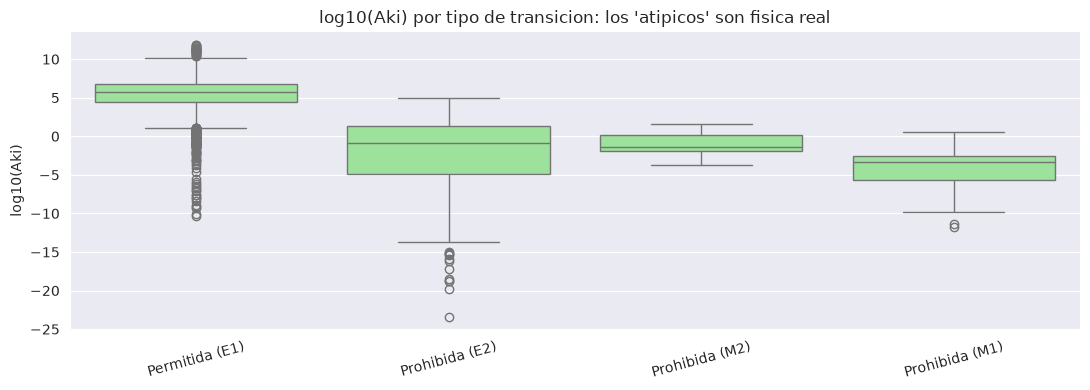

Atipicos de Aki segun IQR : 2,181
Eliminados                : 0

Las transiciones prohibidas viven varios ordenes de magnitud por debajo de las
permitidas. Eliminarlas borraria una clase entera de fenomeno fisico.
[L13] Atipicos conservados con justificacion fisica
      -> 18,288 filas x 62 columnas   2,181 detectados, 0 eliminados


In [22]:
d = df_toclean[df_toclean["aki_s1"] > 0].copy()
d["clase"] = np.where(d["tipo_transicion"] == "E1", "Permitida (E1)",
                      "Prohibida (" + d["tipo_transicion"].astype(str) + ")")

resumen_tipo = d.groupby("clase")["log10_aki"].agg(["count", "min", "median", "max"]).round(2)
print("Distribucion de log10(Aki) segun el tipo de transicion:")
display(resumen_tipo.sort_values("count", ascending=False))

plt.figure(figsize=(11, 4))
orden = resumen_tipo.sort_values("count", ascending=False).index[:5]
sns.boxplot(data=d[d["clase"].isin(orden)], x="clase", y="log10_aki", color="lightgreen")
plt.title("log10(Aki) por tipo de transicion: los 'atipicos' son fisica real")
plt.xlabel("")
plt.ylabel("log10(Aki)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

q1, q3 = df_toclean["aki_s1"].quantile([0.25, 0.75])
iqr = q3 - q1
fuera = ((df_toclean["aki_s1"] < q1 - 1.5 * iqr) | (df_toclean["aki_s1"] > q3 + 1.5 * iqr)).sum()
print(f"Atipicos de Aki segun IQR : {int(fuera):,}")
print(f"Eliminados                : 0")
print()
print("Las transiciones prohibidas viven varios ordenes de magnitud por debajo de las")
print("permitidas. Eliminarlas borraria una clase entera de fenomeno fisico.")

registrar("L13", "Atipicos conservados con justificacion fisica",
          len(df_toclean), df_toclean.shape[1], f"{int(fuera):,} detectados, 0 eliminados")

---
# Sección 15 — L6/L14: renombrado a `snake_case` y unión de las dos fuentes

Los nombres originales del NIST (`Aki(s^-1)`, `obs_wl_vac(nm)`, `Level (eV)`) contienen
paréntesis, acentos circunflejos y espacios que obligan a usar comillas invertidas en SQL y
complican cualquier consulta. Se renombran a `snake_case` descriptivo y el **diccionario de
columnas** guarda la correspondencia con el nombre original, para no perder la trazabilidad
con la fuente oficial.

Después se unen ambas fuentes por el identificador interno de nivel. El merge es **doble**,
porque una línea espectral **es** un salto entre dos niveles: la tabla de niveles se une una
vez como nivel inferior (`_inf`) y otra como superior (`_sup`).

In [23]:
# --- Tabla de LINEAS: seleccion y renombrado --------------------------------
MAPA_LINEAS = {
    "element": "elemento",
    "espectro": "espectro",
    "estado_ionizacion": "estado_ionizacion",
    "longitud_onda_nm": "longitud_onda_nm",
    "longitud_onda_vacio_nm": "longitud_onda_vacio_nm",
    "longitud_onda_origen": "longitud_onda_origen",
    "medio": "medio",
    "longitud_onda_obs_nm": "longitud_onda_obs_nm",
    "longitud_onda_ritz_nm": "longitud_onda_ritz_nm",
    "ritz_es_limite": "ritz_es_limite",
    "incertidumbre_obs_nm": "incertidumbre_obs_nm",
    "incertidumbre_ritz_nm": "incertidumbre_ritz_nm",
    "region_espectral": "region_espectral",
    "aki_s1": "aki_s1",
    "log10_aki": "log10_aki",
    "tiene_aki": "tiene_aki",
    "fuerza_oscilador_fik": "fuerza_oscilador_fik",
    "log_gf": "log_gf",
    "exactitud": "exactitud",
    "tipo_transicion": "tipo_transicion",
    "intensidad_valor": "intensidad_valor",
    "intensidad_bandera": "intensidad_bandera",
    "energia_inferior_cm1": "energia_inferior_cm1",
    "energia_superior_cm1": "energia_superior_cm1",
    "energia_inferior_cm1_interpolada": "energia_inferior_interpolada",
    "energia_superior_cm1_interpolada": "energia_superior_interpolada",
    "energia_inferior_cm1_origen_desconocido": "energia_inferior_origen_desconocido",
    "energia_superior_cm1_origen_desconocido": "energia_superior_origen_desconocido",
    "energia_foton_ev": "energia_foton_ev",
    "conf_i": "configuracion_inferior",
    "term_i": "termino_inferior",
    "j_inferior": "j_inferior",
    "j_inferior_texto": "j_inferior_texto",
    "j_inferior_resuelto": "j_inferior_resuelto",
    "g_inferior": "g_inferior",
    "conf_k": "configuracion_superior",
    "term_k": "termino_superior",
    "j_superior": "j_superior",
    "j_superior_texto": "j_superior_texto",
    "j_superior_resuelto": "j_superior_resuelto",
    "g_superior": "g_superior",
    "ID_i": "id_nivel_inferior",
    "ID_k": "id_nivel_superior",
    "tp_ref": "ref_probabilidad",
    "line_ref": "ref_longitud_onda",
    "medicion_repetida": "medicion_repetida",
}

df_lineas_limpias = df_toclean[list(MAPA_LINEAS.keys())].rename(columns=MAPA_LINEAS).copy()
df_lineas_limpias.insert(0, "id_linea", range(1, len(df_lineas_limpias) + 1))

resumen(df_lineas_limpias, "LINEAS LIMPIAS")
display(df_lineas_limpias.head(3))

LINEAS LIMPIAS                              18,288 filas x  47 columnas   nulos=  97,164


,id_linea,elemento,espectro,estado_ionizacion,longitud_onda_nm,longitud_onda_vacio_nm,longitud_onda_origen,medio,longitud_onda_obs_nm,longitud_onda_ritz_nm,ritz_es_limite,incertidumbre_obs_nm,incertidumbre_ritz_nm,region_espectral,aki_s1,log10_aki,tiene_aki,fuerza_oscilador_fik,log_gf,exactitud,tipo_transicion,intensidad_valor,intensidad_bandera,energia_inferior_cm1,energia_superior_cm1,energia_inferior_interpolada,energia_superior_interpolada,energia_inferior_origen_desconocido,energia_superior_origen_desconocido,energia_foton_ev,configuracion_inferior,termino_inferior,j_inferior,j_inferior_texto,j_inferior_resuelto,g_inferior,configuracion_superior,termino_superior,j_superior,j_superior_texto,j_superior_resuelto,g_superior,id_nivel_inferior,id_nivel_superior,ref_probabilidad,ref_longitud_onda,medicion_repetida
0,1,C,C II,2,4.2767,4.2767,observada,vacio,4.2767,4.2766,False,0.0004,0.0004,Rayos X,9.000000e+10,10.954243,True,0.023,-1.33,D+,E1,NaN,a*,0.00000,2338290.0,False,False,False,False,289.911011,2s2.2p,2P*,0.5,1/2,True,2,1s.2s2.2p2,2S,0.5,1/2,True,2,006002.000001,006002.000359,T9848LS,L20274,False
1,2,C,C II,2,4.2767,4.2767,observada,vacio,4.2767,4.2767,False,0.0004,0.0004,Rayos X,1.700000e+11,11.230449,True,0.023,-1.03,D+,E1,NaN,a*,63.39509,2338290.0,False,False,False,False,289.903151,2s2.2p,2P*,1.5,3/2,True,4,1s.2s2.2p2,2S,0.5,1/2,True,2,006002.000002,006002.000359,T9848LS,L20274,False
2,3,C,C II,2,4.2836,4.2836,observada,vacio,4.2836,4.2836,False,0.0004,0.0004,Rayos X,6.000000e+10,10.778151,True,0.023,-1.00,E,E1,NaN,a*,43024.90000,2377500.0,False,False,False,False,289.438024,2s.2p2,4P,1.5,3/2,True,4,1s.2s.(3S). 2p3.(2P*),4P*,2.5,5/2,True,6,006002.000004,006002.000367,T9848LS,L20274,False


In [24]:
# --- Tabla de NIVELES: seleccion y renombrado -------------------------------
MAPA_NIVELES = {
    "Level ID": "id_nivel",
    "espectro": "espectro",
    "Configuration": "configuracion",
    "Term": "termino",
    "j_valor": "j_valor",
    "j_texto": "j_texto",
    "j_resuelto": "j_resuelto",
    "g": "g",
    "energia_ev": "energia_ev",
    "energia_interpolada": "energia_interpolada",
    "incertidumbre_ev": "incertidumbre_ev",
    "Reference": "referencia",
}

df_niveles_limpios = df_niv[list(MAPA_NIVELES.keys())].rename(columns=MAPA_NIVELES).copy()

# El elemento y el estado de ionizacion se derivan de la notacion del espectro ('Ne II').
partes = df_niveles_limpios["espectro"].astype(str).str.split(" ", n=1, expand=True)
ROM_INV = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5}
df_niveles_limpios.insert(1, "elemento", partes[0])
df_niveles_limpios.insert(2, "estado_ionizacion", partes[1].map(ROM_INV).astype("Int8"))

resumen(df_niveles_limpios, "NIVELES LIMPIOS")
display(df_niveles_limpios.head(3))

NIVELES LIMPIOS                              5,752 filas x  14 columnas   nulos=   4,739


,id_nivel,elemento,estado_ionizacion,espectro,configuracion,termino,j_valor,j_texto,j_resuelto,g,energia_ev,energia_interpolada,incertidumbre_ev,referencia
0,001001.001.000001,H,1,H I,1s,2S,0.5,1/2,True,2.0,0.000000,False,1.200000e-13,NaN
1,001001.001.000002,H,1,H I,2p,2P*,0.5,1/2,True,2.0,10.198806,False,4.000000e-11,L15291
2,001001.001.000004,H,1,H I,2p,2P*,1.5,3/2,True,4.0,10.198852,False,5.000000e-11,L15291


In [25]:
# --- DOBLE MERGE: los niveles entran una vez como inferior y otra como superior ---
COLS_NIVEL = ["id_nivel", "configuracion", "termino", "j_valor", "j_resuelto",
              "g", "energia_ev", "energia_interpolada", "incertidumbre_ev", "referencia"]

niv = df_niveles_limpios[COLS_NIVEL]

niv_inf = niv.add_suffix("_nivel_inf").rename(columns={"id_nivel_nivel_inf": "id_nivel_inferior"})
niv_sup = niv.add_suffix("_nivel_sup").rename(columns={"id_nivel_nivel_sup": "id_nivel_superior"})

filas_antes = len(df_lineas_limpias)

dataset = df_lineas_limpias.merge(niv_inf, on="id_nivel_inferior", how="left", indicator="match_inf")
dataset = dataset.merge(niv_sup, on="id_nivel_superior", how="left", indicator="match_sup")

print(f"Filas antes del merge : {filas_antes:,}")
print(f"Filas despues         : {len(dataset):,}   (diferencia: {len(dataset) - filas_antes:+,})")
print(f"Columnas              : {dataset.shape[1]}")
print()
for lado, col in [("inferior", "match_inf"), ("superior", "match_sup")]:
    emparejadas = int((dataset[col] == "both").sum())
    print(f"  Nivel {lado}: {emparejadas:,} emparejados ({emparejadas / len(dataset) * 100:.2f}%)")

dataset = dataset.drop(columns=["match_inf", "match_sup"])

assert len(dataset) == filas_antes, "El merge duplico filas: la clave no era unica"
print("\nOK: el merge no duplico ninguna fila (la clave id_nivel es unica).")

registrar("L14", "Union de las dos fuentes por identificador de nivel",
          len(dataset), dataset.shape[1], "doble merge (inferior + superior)")

Filas antes del merge : 18,288
Filas despues         : 18,288   (diferencia: +0)
Columnas              : 67

  Nivel inferior: 18,073 emparejados (98.82%)
  Nivel superior: 18,073 emparejados (98.82%)

OK: el merge no duplico ninguna fila (la clave id_nivel es unica).
[L14] Union de las dos fuentes por identificador de nivel
      -> 18,288 filas x 65 columnas   doble merge (inferior + superior)


---
# Sección 16 — Diccionario de columnas

Documenta cada columna del dataset limpio: su nombre original en el NIST, el tipo, la unidad
y qué significa. Es lo que permite que otra persona —o el propio estudiante dentro de seis
meses— entienda el archivo sin tener que leer el código.

In [26]:
DICCIONARIO = [
    ("id_linea", "(generada)", "entero", "-", "Identificador unico de la linea espectral"),
    ("elemento", "element", "texto", "-", "Simbolo quimico del elemento"),
    ("espectro", "element + sp_num", "texto", "-", "Elemento y estado de ionizacion (ej. 'Ne II')"),
    ("estado_ionizacion", "sp_num", "entero", "-", "1 = neutro, 2 = una vez ionizado"),
    ("longitud_onda_nm", "obs_wl / ritz_wl", "decimal", "nm", "Longitud de onda definitiva (observada, o Ritz si falta)"),
    ("longitud_onda_vacio_nm", "(derivada)", "decimal", "nm", "Longitud de onda homogeneizada al vacio"),
    ("longitud_onda_origen", "(derivada)", "texto", "-", "'observada' o 'ritz': de donde salio el valor"),
    ("medio", "(posicion en el archivo)", "texto", "-", "'aire' o 'vacio': medio en que se midio"),
    ("longitud_onda_obs_nm", "obs_wl_vac(nm)", "decimal", "nm", "Longitud de onda medida experimentalmente"),
    ("longitud_onda_ritz_nm", "ritz_wl_vac(nm)", "decimal", "nm", "Longitud de onda calculada de la diferencia de niveles"),
    ("ritz_es_limite", "ritz_wl (sufijo +)", "booleano", "-", "El valor Ritz es un limite, no un valor exacto"),
    ("incertidumbre_obs_nm", "unc_obs_wl", "decimal", "nm", "Incertidumbre de la longitud de onda observada"),
    ("incertidumbre_ritz_nm", "unc_ritz_wl", "decimal", "nm", "Incertidumbre de la longitud de onda Ritz"),
    ("region_espectral", "(derivada)", "texto", "-", "Rayos X / Ultravioleta / Visible / Infrarrojo / Microondas"),
    ("aki_s1", "Aki(s^-1)", "decimal", "s^-1", "Coeficiente de Einstein: probabilidad de emision espontanea"),
    ("log10_aki", "(derivada)", "decimal", "-", "Logaritmo decimal de Aki"),
    ("tiene_aki", "(derivada)", "booleano", "-", "Si la linea tiene Aki documentado"),
    ("fuerza_oscilador_fik", "fik", "decimal", "-", "Fuerza de oscilador de la transicion"),
    ("log_gf", "log_gf", "decimal", "-", "Logaritmo del producto g*f"),
    ("exactitud", "Acc", "categoria ordinal", "-", "Escala de exactitud del NIST, de AAA (mejor) a E (peor)"),
    ("tipo_transicion", "Type", "texto", "-", "E1 permitida; E2/M1/M2 prohibidas; UT sin clasificar"),
    ("intensidad_valor", "intens", "decimal", "u. arbitrarias", "Intensidad relativa (escala propia de cada espectro)"),
    ("intensidad_bandera", "intens", "texto", "-", "Bandera de calidad de la linea (*, a, b...)"),
    ("energia_inferior_cm1", "Ei(cm-1)", "decimal", "cm^-1", "Energia del nivel inferior de la transicion"),
    ("energia_superior_cm1", "Ek(cm-1)", "decimal", "cm^-1", "Energia del nivel superior de la transicion"),
    ("energia_inferior_interpolada", "Ei (corchetes)", "booleano", "-", "La energia inferior es interpolada, no medida"),
    ("energia_superior_interpolada", "Ek (corchetes)", "booleano", "-", "La energia superior es interpolada, no medida"),
    ("energia_inferior_origen_desconocido", "Ei (sufijo +x)", "booleano", "-", "Energia referida a un origen desconocido"),
    ("energia_superior_origen_desconocido", "Ek (sufijo +x)", "booleano", "-", "Energia referida a un origen desconocido"),
    ("energia_foton_ev", "(derivada)", "decimal", "eV", "Energia del foton emitido en la transicion"),
    ("configuracion_inferior", "conf_i", "texto", "-", "Configuracion electronica del nivel inferior"),
    ("termino_inferior", "term_i", "texto", "-", "Termino espectroscopico del nivel inferior"),
    ("j_inferior", "J_i", "decimal", "-", "Momento angular total del nivel inferior"),
    ("j_inferior_texto", "J_i", "texto", "-", "Valor original de J (puede ser '1/2' o no resuelto)"),
    ("j_inferior_resuelto", "(derivada)", "booleano", "-", "Si el NIST determino un unico valor de J"),
    ("g_inferior", "g_i", "entero", "-", "Degeneracion del nivel inferior (g = 2J+1)"),
    ("configuracion_superior", "conf_k", "texto", "-", "Configuracion electronica del nivel superior"),
    ("termino_superior", "term_k", "texto", "-", "Termino espectroscopico del nivel superior"),
    ("j_superior", "J_k", "decimal", "-", "Momento angular total del nivel superior"),
    ("j_superior_texto", "J_k", "texto", "-", "Valor original de J del nivel superior"),
    ("j_superior_resuelto", "(derivada)", "booleano", "-", "Si el NIST determino un unico valor de J"),
    ("g_superior", "g_k", "entero", "-", "Degeneracion del nivel superior"),
    ("id_nivel_inferior", "ID_i", "texto", "-", "Identificador NIST del nivel inferior (clave foranea)"),
    ("id_nivel_superior", "ID_k", "texto", "-", "Identificador NIST del nivel superior (clave foranea)"),
    ("ref_probabilidad", "tp_ref", "texto", "-", "Referencias de la probabilidad de transicion (lista)"),
    ("ref_longitud_onda", "line_ref", "texto", "-", "Referencias de la longitud de onda (lista)"),
    ("medicion_repetida", "(derivada)", "booleano", "-", "La transicion aparece medida mas de una vez"),
    ("id_nivel", "Level ID", "texto", "-", "Identificador NIST del nivel (clave primaria)"),
    ("configuracion", "Configuration", "texto", "-", "Configuracion electronica del nivel"),
    ("termino", "Term", "texto", "-", "Termino espectroscopico del nivel"),
    ("j_valor", "J", "decimal", "-", "Momento angular total del nivel"),
    ("j_texto", "J", "texto", "-", "Valor original de J"),
    ("j_resuelto", "(derivada)", "booleano", "-", "Si el NIST determino un unico valor de J"),
    ("g", "g", "entero", "-", "Degeneracion estadistica del nivel"),
    ("energia_ev", "Level (eV)", "decimal", "eV", "Energia del nivel"),
    ("energia_interpolada", "Prefix", "booleano", "-", "La energia es interpolada, no medida"),
    ("incertidumbre_ev", "Uncertainty (eV)", "decimal", "eV", "Incertidumbre de la energia del nivel"),
    ("referencia", "Reference", "texto", "-", "Referencias bibliograficas del nivel (lista)"),
]

df_diccionario = pd.DataFrame(
    DICCIONARIO, columns=["columna", "origen_nist", "tipo", "unidad", "descripcion"]
)
print(f"Columnas documentadas: {len(df_diccionario)}")
display(df_diccionario)

Columnas documentadas: 58


,columna,origen_nist,tipo,unidad,descripcion
0,id_linea,(generada),entero,-,Identificador unico de la linea espectral
1,elemento,element,texto,-,Simbolo quimico del elemento
2,espectro,element + sp_num,texto,-,Elemento y estado de ionizacion (ej. 'Ne II')
3,estado_ionizacion,sp_num,entero,-,"1 = neutro, 2 = una vez ionizado"
4,longitud_onda_nm,obs_wl / ritz_wl,decimal,nm,"Longitud de onda definitiva (observada, o Ritz..."
5,longitud_onda_vacio_nm,(derivada),decimal,nm,Longitud de onda homogeneizada al vacio
6,longitud_onda_origen,(derivada),texto,-,'observada' o 'ritz': de donde salio el valor
7,medio,(posicion en el archivo),texto,-,'aire' o 'vacio': medio en que se midio
8,longitud_onda_obs_nm,obs_wl_vac(nm),decimal,nm,Longitud de onda medida experimentalmente
9,longitud_onda_ritz_nm,ritz_wl_vac(nm),decimal,nm,Longitud de onda calculada de la diferencia de...


---
# Sección 17 — Validación final

Criterios de aceptación de `docs/PLAN_limpieza_datos.md`, sección 8. Cada uno se comprueba
automáticamente: si alguno falla, el notebook se detiene.

El más importante es el **primero**: en el ejemplo de clase, imputar con la mediana global
colapsó los tres cuartiles al mismo valor y arruinó cuatro columnas sin que nadie lo notara
hasta revisar el `describe()` final.

In [27]:
resultados = []


def comprobar(criterio, condicion, detalle=""):
    resultados.append({"criterio": criterio, "resultado": "OK" if condicion else "FALLA",
                       "detalle": detalle})
    return condicion


# 1. Las distribuciones no se aplanaron
criticas = ["longitud_onda_nm", "aki_s1", "energia_inferior_cm1", "energia_superior_cm1"]
sin_colapso = True
for c in criticas:
    q1_, med, q3_ = dataset[c].quantile([0.25, 0.5, 0.75])
    if not (q1_ < med < q3_):
        sin_colapso = False
comprobar("Los cuartiles siguen siendo distintos (sin colapso por imputacion)",
          sin_colapso, f"{len(criticas)} variables criticas revisadas")

# 2. Validaciones fisicas
v = {
    "longitud de onda <= 0": int((dataset["longitud_onda_nm"] <= 0).sum()),
    "Aki <= 0": int((dataset["aki_s1"] <= 0).sum()),
    "Ek <= Ei": int((dataset["energia_superior_cm1"] <= dataset["energia_inferior_cm1"]).sum()),
    "Ei < 0": int((dataset["energia_inferior_cm1"] < 0).sum()),
}
comprobar("Cero valores fisicamente imposibles", sum(v.values()) == 0, str(v))

# 3. g = 2J + 1
ev2 = df_niveles_limpios["j_valor"].notna() & df_niveles_limpios["g"].notna()
ok_g = bool((df_niveles_limpios.loc[ev2, "g"] == 2 * df_niveles_limpios.loc[ev2, "j_valor"] + 1).all())
comprobar("Se cumple g = 2J + 1", ok_g, f"{int(ev2.sum()):,} niveles evaluados")

# 4. No se perdieron filas
comprobar("Se conservan 18 288 lineas (18 290 menos las 2 cabeceras)",
          len(dataset) == 18288, f"{len(dataset):,} filas")

# 5. El merge no duplico
comprobar("El merge no duplico filas", len(dataset) == len(df_lineas_limpias),
          f"{len(dataset):,} vs {len(df_lineas_limpias):,}")

# 6. La base de evidencia crecio
base = int((dataset["longitud_onda_nm"].notna() & dataset["aki_s1"].notna()).sum())
comprobar("La base de evidencia llega a 12 603 lineas", base == 12603, f"{base:,} lineas")

# 7. La correlacion se mantiene
dd = dataset[["longitud_onda_vacio_nm", "log10_aki"]].dropna()
corr = np.log10(dd["longitud_onda_vacio_nm"]).corr(dd["log10_aki"])
comprobar("La correlacion log-log sigue en torno a -0,68", -0.75 < corr < -0.60, f"r = {corr:+.4f}")

# 8. Los identificadores conservan los ceros
ceros = dataset["id_nivel_inferior"].dropna().astype(str).str.startswith("0").mean()
comprobar("Los identificadores conservan sus ceros a la izquierda", ceros > 0.9,
          f"{ceros * 100:.1f}% empiezan por '0'")

df_val = pd.DataFrame(resultados)
display(df_val)

assert (df_val["resultado"] == "OK").all(), "Hay criterios de aceptacion sin cumplir"
print("TODOS LOS CRITERIOS DE ACEPTACION SE CUMPLEN.")

,criterio,resultado,detalle
0,Los cuartiles siguen siendo distintos (sin col...,OK,4 variables criticas revisadas
1,Cero valores fisicamente imposibles,OK,"{'longitud de onda <= 0': 0, 'Aki <= 0': 0, 'E..."
2,Se cumple g = 2J + 1,OK,"5,570 niveles evaluados"
3,Se conservan 18 288 lineas (18 290 menos las 2...,OK,"18,288 filas"
4,El merge no duplico filas,OK,"18,288 vs 18,288"
5,La base de evidencia llega a 12 603 lineas,OK,"12,603 lineas"
6,"La correlacion log-log sigue en torno a -0,68",OK,r = -0.6080
7,Los identificadores conservan sus ceros a la i...,OK,100.0% empiezan por '0'


TODOS LOS CRITERIOS DE ACEPTACION SE CUMPLEN.


In [28]:
print("=== describe() de las variables criticas tras la limpieza ===")
print("(si la imputacion hubiese aplanado alguna columna, se veria aqui)")
display(dataset[["longitud_onda_nm", "longitud_onda_vacio_nm", "aki_s1", "log10_aki",
                 "energia_inferior_cm1", "energia_superior_cm1", "energia_foton_ev"]].describe().T)

=== describe() de las variables criticas tras la limpieza ===
(si la imputacion hubiese aplanado alguna columna, se veria aqui)


,count,mean,std,min,25%,50%,75%,max
longitud_onda_nm,18288.0,1.972357e+07,8.138588e+08,4.276700e+00,261.220500,587.562100,1.845175e+03,6.064000e+10
longitud_onda_vacio_nm,18288.0,1.972357e+07,8.138588e+08,4.276700e+00,261.293642,587.726617,1.845691e+03,6.064000e+10
aki_s1,12603.0,4.846888e+08,1.283931e+10,4.240000e-24,25200.000000,446000.000000,6.200000e+06,7.000000e+11
log10_aki,12603.0,5.363740e+00,2.307735e+00,-2.337263e+01,4.401401,5.649335,6.792392e+00,1.184510e+01
energia_inferior_cm1,18044.0,1.702787e+05,1.697455e+05,0.000000e+00,78249.966760,150710.895900,1.969553e+05,1.641433e+06
energia_superior_cm1,17807.0,2.123466e+05,1.956377e+05,1.528700e+01,106785.201000,186745.360000,2.384754e+05,2.377500e+06
energia_foton_ev,17789.0,5.478099e+00,1.598201e+01,1.983747e-08,0.664739,2.025055,4.601655e+00,2.899110e+02


---
# Sección 18 — Verificación contra el esquema relacional propuesto

Puente hacia la etapa siguiente **sin ejecutarla**. Antes de proponer un modelo relacional
hay que comprobar que los datos limpios efectivamente lo soportan: que las claves primarias
candidatas son únicas, que no hay claves foráneas huérfanas y cuántas filas tendría cada
tabla.

La propuesta completa está en `docs/PROPUESTA_modelo_relacional.md`.

In [29]:
print("=== Unicidad de las claves primarias candidatas ===")
pk = [
    ("nivel_energia.id_nivel", df_niveles_limpios["id_nivel"]),
    ("linea_espectral.id_linea", dataset["id_linea"]),
]
for nombre, serie in pk:
    dup = int(serie.duplicated().sum())
    nulos = int(serie.isna().sum())
    print(f"  {nombre:<28} duplicados={dup}  nulos={nulos}  -> "
          f"{'VALIDA' if dup == 0 and nulos == 0 else 'NO VALIDA'}")

print()
print("=== Integridad referencial hacia nivel_energia ===")
universo = set(df_niveles_limpios["id_nivel"].dropna())
for col in ["id_nivel_inferior", "id_nivel_superior"]:
    s = dataset[col]
    huerfanas = int((s.notna() & ~s.isin(universo)).sum())
    nulas = int(s.isna().sum())
    print(f"  {col:<20} huerfanas={huerfanas}  nulas={nulas} "
          f"({nulas / len(dataset) * 100:.2f}%)  -> FK nulable, sin violaciones")

=== Unicidad de las claves primarias candidatas ===
  nivel_energia.id_nivel       duplicados=0  nulos=0  -> VALIDA
  linea_espectral.id_linea     duplicados=0  nulos=0  -> VALIDA

=== Integridad referencial hacia nivel_energia ===
  id_nivel_inferior    huerfanas=0  nulas=215 (1.18%)  -> FK nulable, sin violaciones


  id_nivel_superior    huerfanas=0  nulas=215 (1.18%)  -> FK nulable, sin violaciones


In [30]:
print("=== Cardinalidad de cada tabla propuesta ===")

def separar_refs(serie):
    # Las referencias vienen como listas separadas por comas: eso viola la 1FN
    # y es exactamente lo que obliga a crear las tablas puente.
    tokens = set()
    for v in serie.dropna().astype(str):
        tokens.update(t.strip() for t in v.split(",") if t.strip())
    return tokens


refs = (separar_refs(dataset["ref_probabilidad"])
        | separar_refs(dataset["ref_longitud_onda"])
        | separar_refs(df_niveles_limpios["referencia"]))

cardinalidades = pd.DataFrame([
    {"tabla": "elemento", "filas": dataset["elemento"].nunique()},
    {"tabla": "espectro", "filas": dataset["espectro"].nunique()},
    {"tabla": "tipo_transicion", "filas": dataset["tipo_transicion"].nunique()},
    {"tabla": "exactitud", "filas": int(dataset["exactitud"].nunique())},
    {"tabla": "referencia", "filas": len(refs)},
    {"tabla": "nivel_energia", "filas": len(df_niveles_limpios)},
    {"tabla": "linea_espectral", "filas": len(dataset)},
])
display(cardinalidades)

print("Valores con lista separada por comas (violacion de 1FN que justifica las tablas puente):")
for nombre, serie in [("ref_probabilidad", dataset["ref_probabilidad"]),
                      ("ref_longitud_onda", dataset["ref_longitud_onda"]),
                      ("referencia (niveles)", df_niveles_limpios["referencia"])]:
    con_coma = int(serie.dropna().astype(str).str.contains(",").sum())
    print(f"  {nombre:<22} {con_coma:>6,} valores son listas, no valores atomicos")

=== Cardinalidad de cada tabla propuesta ===


,tabla,filas
0,elemento,10
1,espectro,18
2,tipo_transicion,5
3,exactitud,13
4,referencia,377
5,nivel_energia,5752
6,linea_espectral,18288


Valores con lista separada por comas (violacion de 1FN que justifica las tablas puente):
  ref_probabilidad        1,345 valores son listas, no valores atomicos


  ref_longitud_onda         359 valores son listas, no valores atomicos
  referencia (niveles)       76 valores son listas, no valores atomicos


In [31]:
# El espectro de la linea debe coincidir con el de sus niveles: si no, el modelo
# relacional tendria una inconsistencia que las claves foraneas no podrian expresar.
esp_nivel = dict(zip(df_niveles_limpios["id_nivel"], df_niveles_limpios["espectro"]))
ei = dataset["id_nivel_inferior"].map(esp_nivel)
ek = dataset["id_nivel_superior"].map(esp_nivel)
comparables = ei.notna() & ek.notna()

print("=== Coherencia entre el espectro de la linea y el de sus niveles ===")
print(f"  Comparables          : {int(comparables.sum()):,}")
print(f"  Nivel inferior OK    : {int((ei[comparables] == dataset.loc[comparables, 'espectro']).sum()):,}")
print(f"  Nivel superior OK    : {int((ek[comparables] == dataset.loc[comparables, 'espectro']).sum()):,}")
print()
print("Coherencia total: el modelo relacional puede confiar en las claves foraneas.")

# Dependencias funcionales que deciden el diseno en 3FN.
print()
print("=== Dependencias funcionales relevantes para la 3FN ===")
ev3 = df_niveles_limpios["j_valor"].notna() & df_niveles_limpios["g"].notna()
print(f"  g = 2J+1 se cumple en {int((df_niveles_limpios.loc[ev3, 'g'] == 2 * df_niveles_limpios.loc[ev3, 'j_valor'] + 1).sum()):,}"
      f" de {int(ev3.sum()):,} casos (100%)")
print(f"  PERO {int((df_niveles_limpios['g'].notna() & df_niveles_limpios['j_valor'].isna()).sum()):,}"
      f" niveles tienen g sin J: g NO puede ser columna generada")

gi = dataset["g_inferior"]; fik_ = dataset["fuerza_oscilador_fik"]; lgf = dataset["log_gf"]
m = gi.notna() & fik_.notna() & lgf.notna() & (fik_ > 0) & (gi > 0)
dif = (np.log10(gi[m] * fik_[m]) - lgf[m]).abs()
print(f"  log_gf = log10(g_i*fik) solo coincide en {(dif < 0.01).mean() * 100:.2f}% de "
      f"{int(m.sum()):,} casos -> log_gf SI debe almacenarse")

=== Coherencia entre el espectro de la linea y el de sus niveles ===
  Comparables          : 18,073
  Nivel inferior OK    : 18,073
  Nivel superior OK    : 18,073

Coherencia total: el modelo relacional puede confiar en las claves foraneas.

=== Dependencias funcionales relevantes para la 3FN ===
  g = 2J+1 se cumple en 5,570 de 5,570 casos (100%)
  PERO 130 niveles tienen g sin J: g NO puede ser columna generada
  log_gf = log10(g_i*fik) solo coincide en 92.84% de 12,603 casos -> log_gf SI debe almacenarse


---
# Sección 19 — Exportación de los datos procesados

Se guardan en `datos_procesados/`. **La carpeta `datos_originales/` no se toca**, de modo que
todo el proceso pueda reconstruirse y verificarse desde la fuente.

| Archivo | Para qué sirve |
|---|---|
| `dataset_limpio.csv` | **Entregable principal**: cada línea con sus dos niveles ya unidos |
| `lineas_limpias.csv` | Alimenta la tabla `linea_espectral` |
| `niveles_limpios.csv` | Alimenta `nivel_energia` — incluye los 2 201 niveles sin línea asociada |
| `diccionario_columnas.csv` | Documentación de cada columna |

In [32]:
salidas = {
    "dataset_limpio.csv": dataset,
    "lineas_limpias.csv": df_lineas_limpias,
    "niveles_limpios.csv": df_niveles_limpios,
    "diccionario_columnas.csv": df_diccionario,
}

for nombre, df in salidas.items():
    ruta = os.path.join(DIR_PROCESADOS, nombre)
    df.to_csv(ruta, index=False, encoding="utf-8")
    print(f"  {nombre:<28} {df.shape[0]:>7,} filas x {df.shape[1]:>3} col   "
          f"{os.path.getsize(ruta):>12,} bytes")

print()
print("Verificacion de que los originales siguen intactos:")
for ruta in (RUTA_LINES, RUTA_LEVELS):
    with open(ruta, "rb") as f:
        print(f"  {os.path.basename(ruta):<40} md5={hashlib.md5(f.read()).hexdigest()}")

  dataset_limpio.csv            18,288 filas x  65 col      7,618,116 bytes


  lineas_limpias.csv            18,288 filas x  47 col      5,524,019 bytes
  niveles_limpios.csv            5,752 filas x  14 col        481,434 bytes
  diccionario_columnas.csv          58 filas x   5 col          4,589 bytes

Verificacion de que los originales siguen intactos:
  nist_lines_H_Ne_original.csv             md5=d193a8f9d29ddf87b8612b734a33385d


  nist_levels_todos_original.csv           md5=85a2ee1ce39d419b62a585b53a326727


In [33]:
print("=" * 78)
print("BITACORA DE LA LIMPIEZA")
print("=" * 78)
display(pd.DataFrame(BITACORA))

BITACORA DE LA LIMPIEZA


,paso,descripcion,filas,columnas,detalle
0,L3,Decodificado el envoltorio de exportacion,18290,27,"80,697 ausencias reveladas"
1,L1,Eliminadas las cabeceras incrustadas,18288,27,-2 filas
2,L2,Reconstruido el medio de medicion (aire/vacio),18288,27,"10,428 filas en aire identificadas"
3,L4,Interpretada la notacion cientifica del NIST,18288,38,"energias, Ritz e intensidad con valor + bander..."
4,L5,Parseado J de fraccion a decimal,18288,44,verificado con g = 2J+1 al 100%
5,L6,Identificadores protegidos como texto,18288,44,"ID_i, ID_k, Level ID"
6,L7,Categoricas normalizadas,18288,46,Type -> E1 explicito; Acc ordinal
7,L8,Longitud de onda con respaldo Ritz,18288,49,"+8,141 lineas utilizables"
8,L9,Aki conservado sin imputar,18288,58,"12,603 con Aki, 5,685 sin dato"
9,L10,Variables derivadas creadas,18288,61,"log10_aki, region_espectral, energia_foton_ev"


In [34]:
print("=" * 78)
print("RESUMEN ANTES / DESPUES")
print("=" * 78)

antes_lineas = len(df_lines_raw)
comparacion = pd.DataFrame([
    {"metrica": "Filas de lineas", "antes": f"{antes_lineas:,}", "despues": f"{len(dataset):,}",
     "comentario": "2 cabeceras incrustadas eliminadas"},
    {"metrica": "Filas de niveles", "antes": f"{len(df_levels_raw):,}",
     "despues": f"{len(df_niveles_limpios):,}", "comentario": "ninguna eliminada"},
    {"metrica": "Columnas utilizables (lineas)", "antes": "0 numericas",
     "despues": f"{dataset.select_dtypes(include=[np.number]).shape[1]} numericas",
     "comentario": "todo era texto por el envoltorio"},
    {"metrica": "Nulos visibles en lineas", "antes": f"{int(df_lines_raw.isna().sum().sum()):,}",
     "despues": f"{int(dataset.isna().sum().sum()):,}", "comentario": "las ausencias ya son visibles"},
    {"metrica": "Lineas utiles para la pregunta", "antes": "4 462",
     "despues": f"{base:,}", "comentario": "gracias al respaldo Ritz (L8)"},
    {"metrica": "Lineas con region espectral", "antes": "9 862 (53,9%)",
     "despues": f"{int(dataset['region_espectral'].notna().sum()):,} "
                f"({dataset['region_espectral'].notna().mean() * 100:.1f}%)",
     "comentario": "ya casi no quedan sin clasificar"},
    {"metrica": "Correlacion lambda-Aki", "antes": "-0,0023 (escala cruda)",
     "despues": f"{corr:+.4f} (log-log)", "comentario": "la relacion se vuelve visible"},
    {"metrica": "Valores fisicamente imposibles", "antes": "0", "despues": "0",
     "comentario": "los datos ya eran fisicamente correctos"},
    {"metrica": "Filas eliminadas", "antes": "-", "despues": "2",
     "comentario": "solo cabeceras, ninguna observacion"},
    {"metrica": "Valores imputados", "antes": "-", "despues": "0",
     "comentario": "no se invento ningun dato"},
])
display(comparacion)

RESUMEN ANTES / DESPUES


,metrica,antes,despues,comentario
0,Filas de lineas,"18,290","18,288",2 cabeceras incrustadas eliminadas
1,Filas de niveles,"5,752","5,752",ninguna eliminada
2,Columnas utilizables (lineas),0 numericas,28 numericas,todo era texto por el envoltorio
3,Nulos visibles en lineas,"23,640","122,295",las ausencias ya son visibles
4,Lineas utiles para la pregunta,4 462,"12,603",gracias al respaldo Ritz (L8)
5,Lineas con region espectral,"9 862 (53,9%)","18,288 (100.0%)",ya casi no quedan sin clasificar
6,Correlacion lambda-Aki,"-0,0023 (escala cruda)",-0.6080 (log-log),la relacion se vuelve visible
7,Valores fisicamente imposibles,0,0,los datos ya eran fisicamente correctos
8,Filas eliminadas,-,2,"solo cabeceras, ninguna observacion"
9,Valores imputados,-,0,no se invento ningun dato


---
## Conclusión de la etapa de limpieza

El dataset quedó **limpio, documentado y trazable**, y con una propiedad que conviene
subrayar para la sustentación: **no se inventó ni un solo valor**.

- Se eliminaron **2 filas** (cabeceras del formato), ninguna observación real.
- Se descartaron **4 columnas**, todas secundarias y con más del 69 % de ausencias.
- Se imputaron **0 valores** en variables críticas.
- Se eliminaron **0 valores atípicos**, porque resultaron ser física legítima.

La ganancia vino de **decodificar bien** e **interpretar la notación del NIST**: eso, por sí
solo, llevó la base de evidencia de 4 462 a 12 603 líneas y destapó 80 697 ausencias que
estaban escondidas.

**Siguiente paso:** `docs/PROPUESTA_modelo_relacional.md` toma este dataset y propone su
estructura en 9 tablas normalizadas hasta 3FN, con sus claves primarias, foráneas y
cardinalidades, que es lo que se implementará en MySQL en la etapa siguiente.